---
## 0. Setup & Imports

In [43]:
# Install any missing packages
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['plotly', 'statsmodels', 'kaleido']:
    try:
        __import__(pkg)
    except ImportError:
        install(pkg)

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import sqlite3
import os
import warnings
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DB_PATH     = 'housing.db'
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## Zillow ZHVI Data: Loading & Cleaning

In [106]:
# ── Download Zillow ZHVI Metro Data ─────────────────────────────────────────
# Source: https://www.zillow.com/research/data/
# ZHVI All Homes (SFR, Condo/Co-op), Smoothed, Seasonally Adjusted — Metro level

ZILLOW_URL = (
    'https://files.zillowstatic.com/research/public_csvs/zhvi/'
    'Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'
)
LOCAL_ZILLOW = 'zillow_zhvi_metro.csv'

if not os.path.exists(LOCAL_ZILLOW):
    print('Downloading Zillow ZHVI data...')
    resp = requests.get(ZILLOW_URL, timeout=60)
    resp.raise_for_status()
    with open(LOCAL_ZILLOW, 'wb') as f:
        f.write(resp.content)
    print(f'Saved to {LOCAL_ZILLOW}')
else:
    print(f'Using cached file: {LOCAL_ZILLOW}')

zhvi_raw = pd.read_csv(LOCAL_ZILLOW)
print(f'Raw shape: {zhvi_raw.shape}')
zhvi_raw.head(3)

Using cached file: zillow_zhvi_metro.csv
Raw shape: (895, 318)


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
0,102001,0,United States,country,NaN,120245.401273,120456.951481,120719.304889,121282.001451,121929.597731,...,356520.996883,355847.084537,355240.355926,354820.996430,354597.242836,354834.693617,355261.536448,355925.870866,356703.081920,357444.592267
1,394913,1,"New York, NY",msa,NY,216213.074441,217131.858016,218059.151183,219938.205956,221884.032245,...,684527.238403,686280.002733,687742.249805,688904.163124,689687.004711,691074.903618,693389.288933,696701.313817,700090.397649,703126.246109
2,753899,2,"Los Angeles, CA",msa,CA,219357.633964,220173.922681,221261.211467,223424.550904,225790.566038,...,943189.059655,938463.706961,934153.202642,931587.011384,930526.406111,931572.591632,933964.652130,937248.897282,941169.205188,943673.884613


In [100]:
# ── Reshape Wide → Long ──────────────────────────────────────────────────────
# Raw CSV: one row per metro, one column per month.
# We melt into (RegionName, Date, ZHVI) long format for easier analysis.

meta_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
date_cols = [c for c in zhvi_raw.columns if c not in meta_cols]

zhvi_long = zhvi_raw.melt(
    id_vars=meta_cols,
    value_vars=date_cols,
    var_name='Date',
    value_name='ZHVI'
)

zhvi_long['Date'] = pd.to_datetime(zhvi_long['Date'])
zhvi_long = zhvi_long.dropna(subset=['ZHVI'])

# Keep only metro-level rows (RegionType == 'msa')
zhvi_metro = zhvi_long[zhvi_long['RegionType'] == 'msa'].copy()
zhvi_metro = zhvi_metro.sort_values(['RegionName', 'Date']).reset_index(drop=True)

print(f'Total metro rows : {len(zhvi_metro):,}')
print(f'Unique metros    : {zhvi_metro["RegionName"].nunique()}')
print(f'Date range       : {zhvi_metro["Date"].min().date()} to {zhvi_metro["Date"].max().date()}')
zhvi_metro.head()

Total metro rows : 230,556
Unique metros    : 894
Date range       : 2000-01-31 to 2026-01-31


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI
0,394297,677,"Aberdeen, SD",msa,SD,2009-02-28,125066.417884
1,394297,677,"Aberdeen, SD",msa,SD,2009-03-31,125079.142534
2,394297,677,"Aberdeen, SD",msa,SD,2009-04-30,124888.758875
3,394297,677,"Aberdeen, SD",msa,SD,2009-05-31,124780.972274
4,394297,677,"Aberdeen, SD",msa,SD,2009-06-30,124593.031335


In [78]:
# ── Basic Descriptive Stats ──────────────────────────────────────────────────
latest_date = zhvi_metro['Date'].max()
snapshot    = zhvi_metro[zhvi_metro['Date'] == latest_date][['RegionName', 'StateName', 'ZHVI']]

print(f'Latest snapshot ({latest_date.date()}):')
print(snapshot['ZHVI'].describe().apply(lambda x: f'${x:,.0f}'))
print('\nTop 5 most expensive metros:')
print(snapshot.nlargest(5, 'ZHVI')[['RegionName','ZHVI']].to_string(index=False))
print('\nBottom 5 least expensive metros:')
print(snapshot.nsmallest(5, 'ZHVI')[['RegionName','ZHVI']].to_string(index=False))

Latest snapshot (2026-01-31):
count          $894
mean       $286,741
std        $173,215
min         $47,226
25%        $181,633
50%        $242,011
75%        $338,351
max      $1,568,567
Name: ZHVI, dtype: object

Top 5 most expensive metros:
        RegionName         ZHVI
      San Jose, CA 1.568567e+06
Vineyard Haven, MA 1.479928e+06
       Jackson, WY 1.352900e+06
       Edwards, CO 1.282352e+06
         Heber, UT 1.114767e+06

Bottom 5 least expensive metros:
      RegionName         ZHVI
      Helena, AR 47225.520692
  Clarksdale, MS 47381.410719
  Greenville, MS 48179.052194
Forrest City, AR 73021.762192
       Selma, AL 84168.587448


---
## SQLite Database: Store & Query

In [127]:
# ── Write to SQLite ──────────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)

zhvi_metro.to_sql('zhvi', conn, if_exists='replace', index=False)
print(f'Table "zhvi" written to {DB_PATH}')

pd.read_sql('SELECT COUNT(*) AS total_rows FROM zhvi', conn)

Table "zhvi" written to housing.db


,total_rows
0,230556


In [136]:
# ── SQL Query 1: Price Growth Per Metro ──────────────────────────────────────
# Computes % growth from Jan 2000 to latest, and Jan 2009 to Dec 2024

growth_sql = """
WITH base_2000 AS (
    SELECT RegionID, RegionName, StateName, ZHVI AS zhvi_2000
    FROM zhvi
    WHERE Date = (SELECT MIN(Date) FROM zhvi WHERE Date >= '2000-01-01')
),
base_2009 AS (
    SELECT RegionID, ZHVI AS zhvi_2009
    FROM zhvi
    WHERE Date = (SELECT MIN(Date) FROM zhvi WHERE Date >= '2009-01-01')
),
latest AS (
    SELECT RegionID, ZHVI AS zhvi_latest
    FROM zhvi
    WHERE Date = (SELECT MAX(Date) FROM zhvi)
),
end_2024 AS (
    SELECT RegionID, ZHVI AS zhvi_2024
    FROM zhvi
    WHERE Date = (SELECT MAX(Date) FROM zhvi WHERE Date <= '2024-12-31')
)
SELECT
    b.RegionID,
    b.RegionName,
    b.StateName,
    ROUND(b.zhvi_2000,   0) AS zhvi_2000,
    ROUND(b9.zhvi_2009,  0) AS zhvi_2009,
    ROUND(e24.zhvi_2024, 0) AS zhvi_2024,
    ROUND(l.zhvi_latest, 0) AS zhvi_latest,
    ROUND((l.zhvi_latest  - b.zhvi_2000)  / b.zhvi_2000  * 100, 1) AS pct_growth_2000_latest,
    ROUND((e24.zhvi_2024  - b9.zhvi_2009) / b9.zhvi_2009 * 100, 1) AS pct_growth_2009_2024
FROM base_2000 b
JOIN base_2009  b9  ON b.RegionID = b9.RegionID
JOIN latest     l   ON b.RegionID = l.RegionID
JOIN end_2024   e24 ON b.RegionID = e24.RegionID
WHERE b.zhvi_2000  IS NOT NULL
  AND b9.zhvi_2009 IS NOT NULL
ORDER BY pct_growth_2000_latest DESC
"""

growth_df = pd.read_sql(growth_sql, conn)
print(f'Growth records: {len(growth_df)}')
growth_df.head(10)

Growth records: 428


,RegionID,RegionName,StateName,zhvi_2000,zhvi_2009,zhvi_2024,zhvi_latest,pct_growth_2000_latest,pct_growth_2009_2024
0,394736,"Kapaa, HI",HI,154102.0,407791.0,1012076.0,991658.0,543.5,148.2
1,395004,"Prineville, OR",OR,88936.0,158705.0,456262.0,459753.0,416.9,187.5
2,394731,"Kahului, HI",HI,191801.0,475961.0,1065317.0,988552.0,415.4,123.8
3,394476,"Clewiston, FL",FL,53539.0,90450.0,279538.0,271874.0,407.8,209.1
4,753881,"Glenwood Springs, CO",CO,191404.0,345291.0,910413.0,958259.0,400.6,163.7
5,753921,"Steamboat Springs, CO",CO,220316.0,393326.0,1087426.0,1099875.0,399.2,176.5
6,394928,"Ocean City, NJ",NJ,161975.0,409067.0,732966.0,765863.0,372.8,79.2
7,753925,"Vineyard Haven, MA",MA,323150.0,604643.0,1465624.0,1479928.0,358.0,142.4
8,394759,"Laconia, NH",NH,108456.0,212159.0,475640.0,489854.0,351.7,124.2
9,395059,"San Jose, CA",CA,356515.0,525022.0,1579726.0,1568567.0,340.0,200.9


In [140]:
# ── SQL Query 2: Monthly Price Spread (Gap Analysis) ─────────────────────────
# Tracks the spread between the most and least expensive metros each month

spread_sql = """
SELECT
    Date,
    MAX(ZHVI)               AS top_zhvi,
    MIN(ZHVI)               AS bot_zhvi,
    AVG(ZHVI)               AS avg_zhvi,
    (MAX(ZHVI) - MIN(ZHVI)) AS spread_abs,
    (MAX(ZHVI) / MIN(ZHVI)) AS spread_ratio
FROM zhvi
GROUP BY Date
ORDER BY Date
"""

spread_df = pd.read_sql(spread_sql, conn)
spread_df['Date'] = pd.to_datetime(spread_df['Date'])

# Add 25th/75th percentiles via pandas (not supported in SQLite)
pct_df = (
    zhvi_metro.groupby('Date')['ZHVI']
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: 'p25_zhvi', 0.75: 'p75_zhvi'})
    .reset_index()
)
spread_df = spread_df.merge(pct_df, on='Date')

print(f'Spread records: {len(spread_df)}')
spread_df.tail()

Spread records: 313


,Date,top_zhvi,bot_zhvi,avg_zhvi,spread_abs,spread_ratio,p25_zhvi,p75_zhvi
308,2025-09-30,1.524608e+06,46486.936299,283532.870636,1.478122e+06,32.796493,178850.438905,334894.644380
309,2025-10-31,1.535049e+06,46898.076971,284027.475456,1.488151e+06,32.731597,179371.789335,335838.851996
310,2025-11-30,1.549829e+06,47244.252890,284765.275273,1.502585e+06,32.804609,179727.652665,336560.511072
311,2025-12-31,1.563571e+06,47430.605766,285718.893473,1.516141e+06,32.965452,180982.464305,337328.532758
312,2026-01-31,1.568567e+06,47225.520692,286740.542675,1.521341e+06,33.214392,181632.530056,338351.193854


In [141]:
# ── SQL Query 3: State-Level Aggregates ──────────────────────────────────────
state_agg = (
    growth_df
    .dropna(subset=['StateName'])
    .groupby('StateName')
    .agg(
        num_metros       = ('RegionID', 'count'),
        median_growth_00 = ('pct_growth_2000_latest', 'median'),
        median_growth_09 = ('pct_growth_2009_2024',   'median'),
        median_zhvi      = ('zhvi_latest', 'median')
    )
    .round(1)
    .reset_index()
    .sort_values('median_growth_00', ascending=False)
)

print('State-level aggregates (top 10 by growth):')
state_agg.head(10)

State-level aggregates (top 10 by growth):


,StateName,num_metros,median_growth_00,median_growth_09,median_zhvi
10,HI,3,415.4,123.8,988552.0
26,NH,5,289.2,113.4,468928.0
20,ME,4,280.2,113.6,308589.5
12,ID,1,264.5,112.6,399402.0
3,AZ,8,262.6,97.3,359369.5
34,RI,1,261.4,92.9,501113.0
4,CA,20,253.8,117.4,798236.5
41,WA,7,241.9,108.3,518309.0
32,OR,14,241.8,97.8,442974.5
40,VT,4,224.8,74.2,367687.5


---
## Visualization: Price Divergence Over Time

In [144]:
def find_metro(name, df):
    city = name.split(',')[0].split('-')[0].strip()
    matches = df[df['RegionName'].str.contains(city, case=False, na=False)]['RegionName'].unique()
    return matches[0] if len(matches) > 0 else None

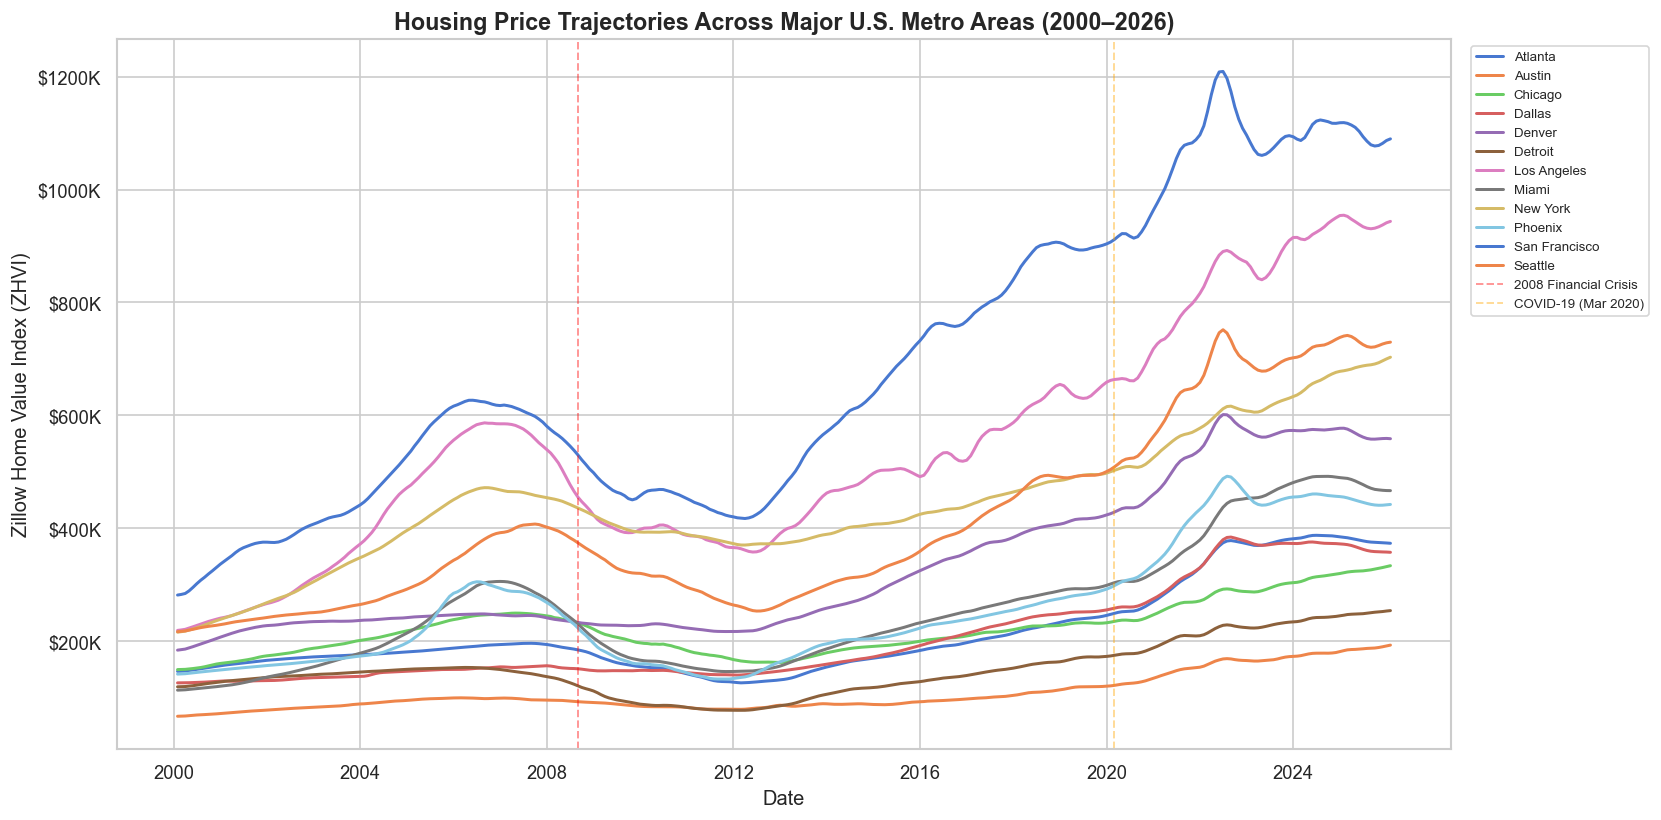

Figure 1 saved.


In [142]:
# ── Fig 1: Top Metro Price Trajectories (Static Line Chart) ─────────────────
notable_metros = [
    'New York, NY', 'Los Angeles, CA', 'San Francisco, CA',
    'Dallas, TX', 'Miami, FL', 'Austin, TX',
    'Chicago, IL', 'Seattle, WA', 'Denver, CO',
    'Phoenix, AZ', 'Detroit, MI', 'Atlanta, GA',
]

matched = [find_metro(m, zhvi_metro) for m in notable_metros]
matched = [m for m in matched if m is not None]
plot_df  = zhvi_metro[zhvi_metro['RegionName'].isin(matched)].copy()

fig, ax = plt.subplots(figsize=(14, 7))
for name, grp in plot_df.groupby('RegionName'):
    ax.plot(grp['Date'], grp['ZHVI'] / 1e3, linewidth=1.8, label=name.split(',')[0])

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.axvline(pd.Timestamp('2008-09-01'), color='red',    linestyle='--', alpha=0.4, linewidth=1.2, label='2008 Financial Crisis')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.4, linewidth=1.2, label='COVID-19 (Mar 2020)')
ax.set_title('Housing Price Trajectories Across Major U.S. Metro Areas (2000–2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Zillow Home Value Index (ZHVI)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_metro_trajectories.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

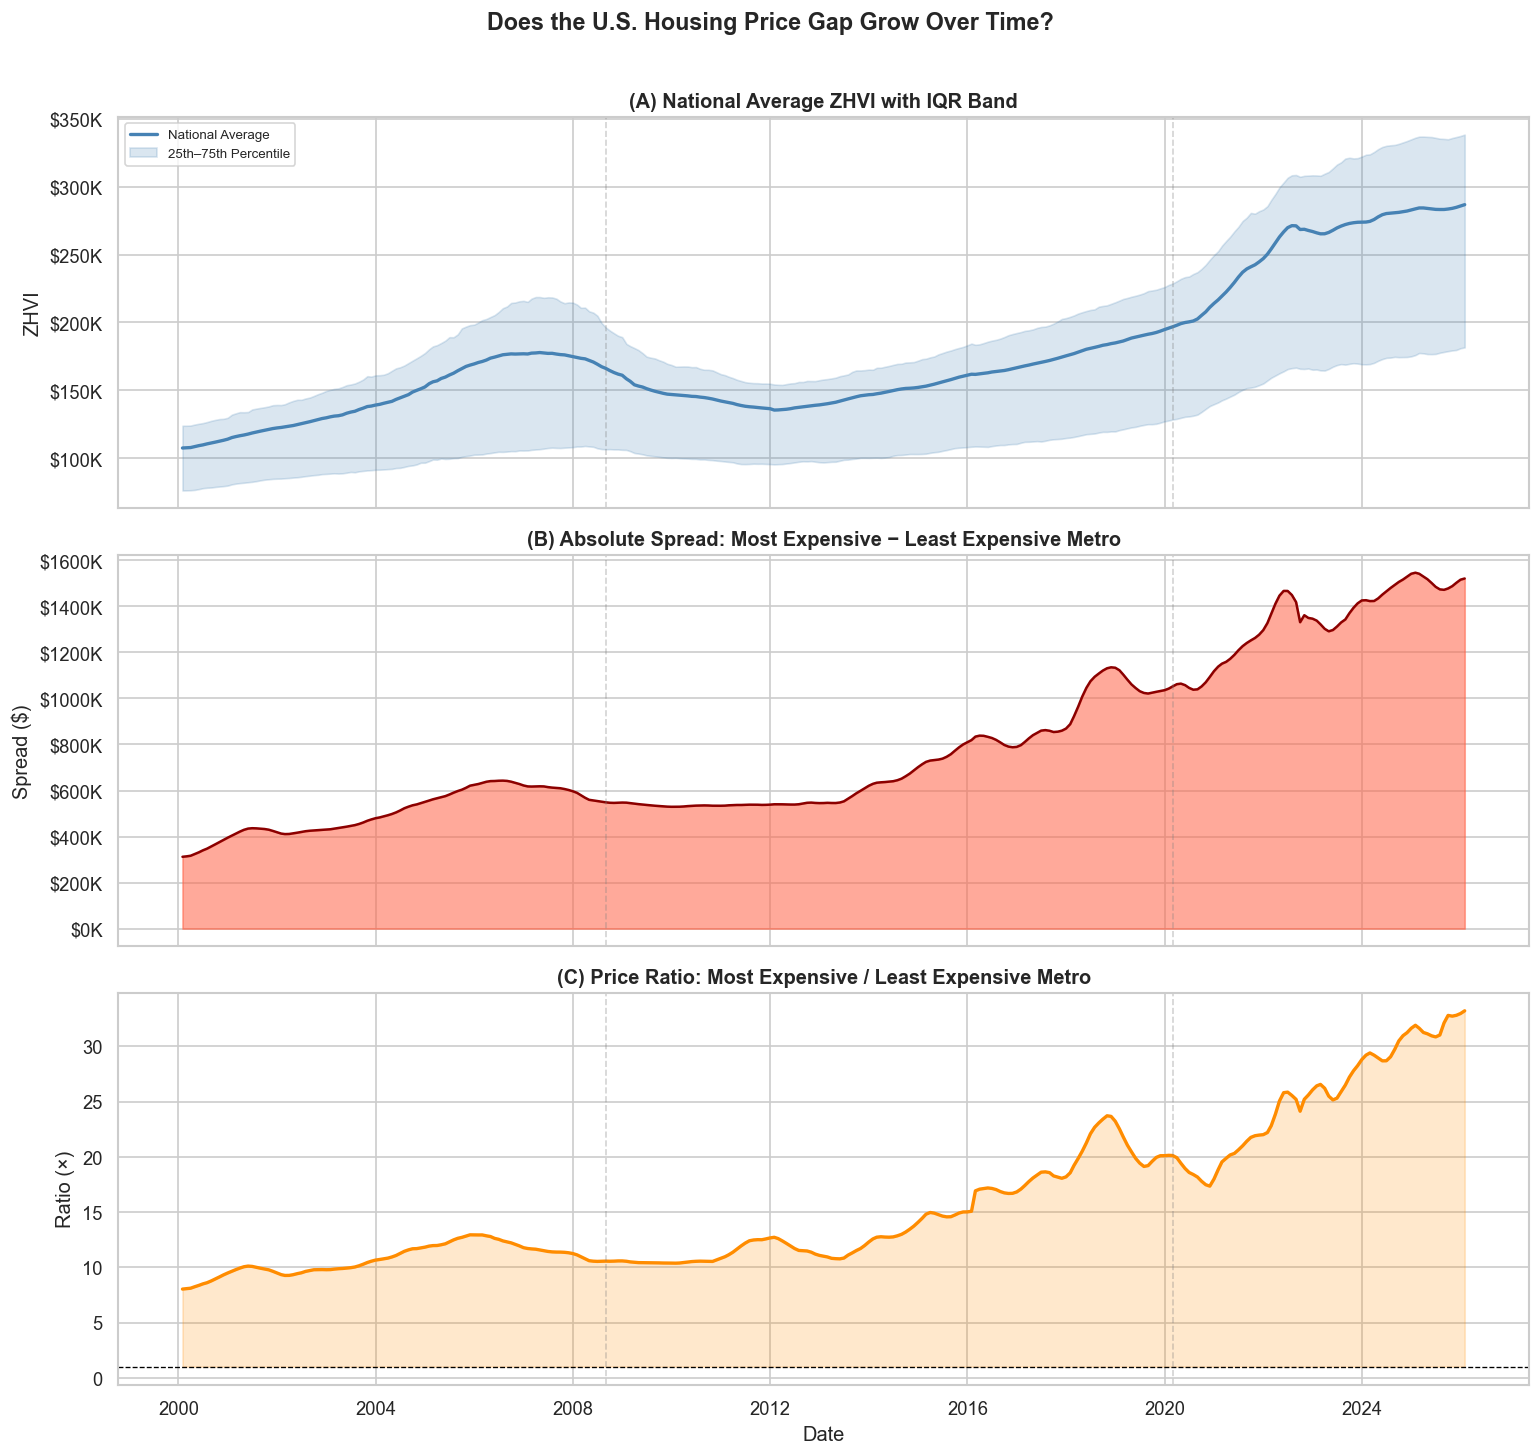

Figure 2 saved.


In [155]:
# ── Fig 2: Does the Gap Grow? Price Divergence Over Time ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

# Panel A: Average ZHVI with IQR band
ax = axes[0]
ax.plot(spread_df['Date'], spread_df['avg_zhvi'] / 1e3,
        color='steelblue', linewidth=2, label='National Average')
ax.fill_between(spread_df['Date'],
                spread_df['p25_zhvi'] / 1e3,
                spread_df['p75_zhvi'] / 1e3,
                alpha=0.2, color='steelblue', label='25th–75th Percentile')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.set_title('(A) National Average ZHVI with IQR Band', fontweight='bold')
ax.set_ylabel('ZHVI')
ax.legend(fontsize=8)

# Panel B: Absolute spread (max − min)
ax = axes[1]
ax.fill_between(spread_df['Date'], spread_df['spread_abs'] / 1e3, alpha=0.55, color='tomato')
ax.plot(spread_df['Date'], spread_df['spread_abs'] / 1e3, color='darkred', linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.set_title('(B) Absolute Spread: Most Expensive − Least Expensive Metro', fontweight='bold')
ax.set_ylabel('Spread ($)')

# Panel C: Ratio (max / min) — normalizes for overall price level
ax = axes[2]
ax.plot(spread_df['Date'], spread_df['spread_ratio'], color='darkorange', linewidth=2)
ax.fill_between(spread_df['Date'], 1, spread_df['spread_ratio'], alpha=0.2, color='darkorange')
ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_title('(C) Price Ratio: Most Expensive / Least Expensive Metro', fontweight='bold')
ax.set_ylabel('Ratio (×)')
ax.set_xlabel('Date')

for ax in axes:
    ax.axvline(pd.Timestamp('2008-09-01'), color='gray', linestyle='--', alpha=0.35, linewidth=1)
    ax.axvline(pd.Timestamp('2020-03-01'), color='gray', linestyle='--', alpha=0.35, linewidth=1)

fig.suptitle('Does the U.S. Housing Price Gap Grow Over Time?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_price_divergence.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

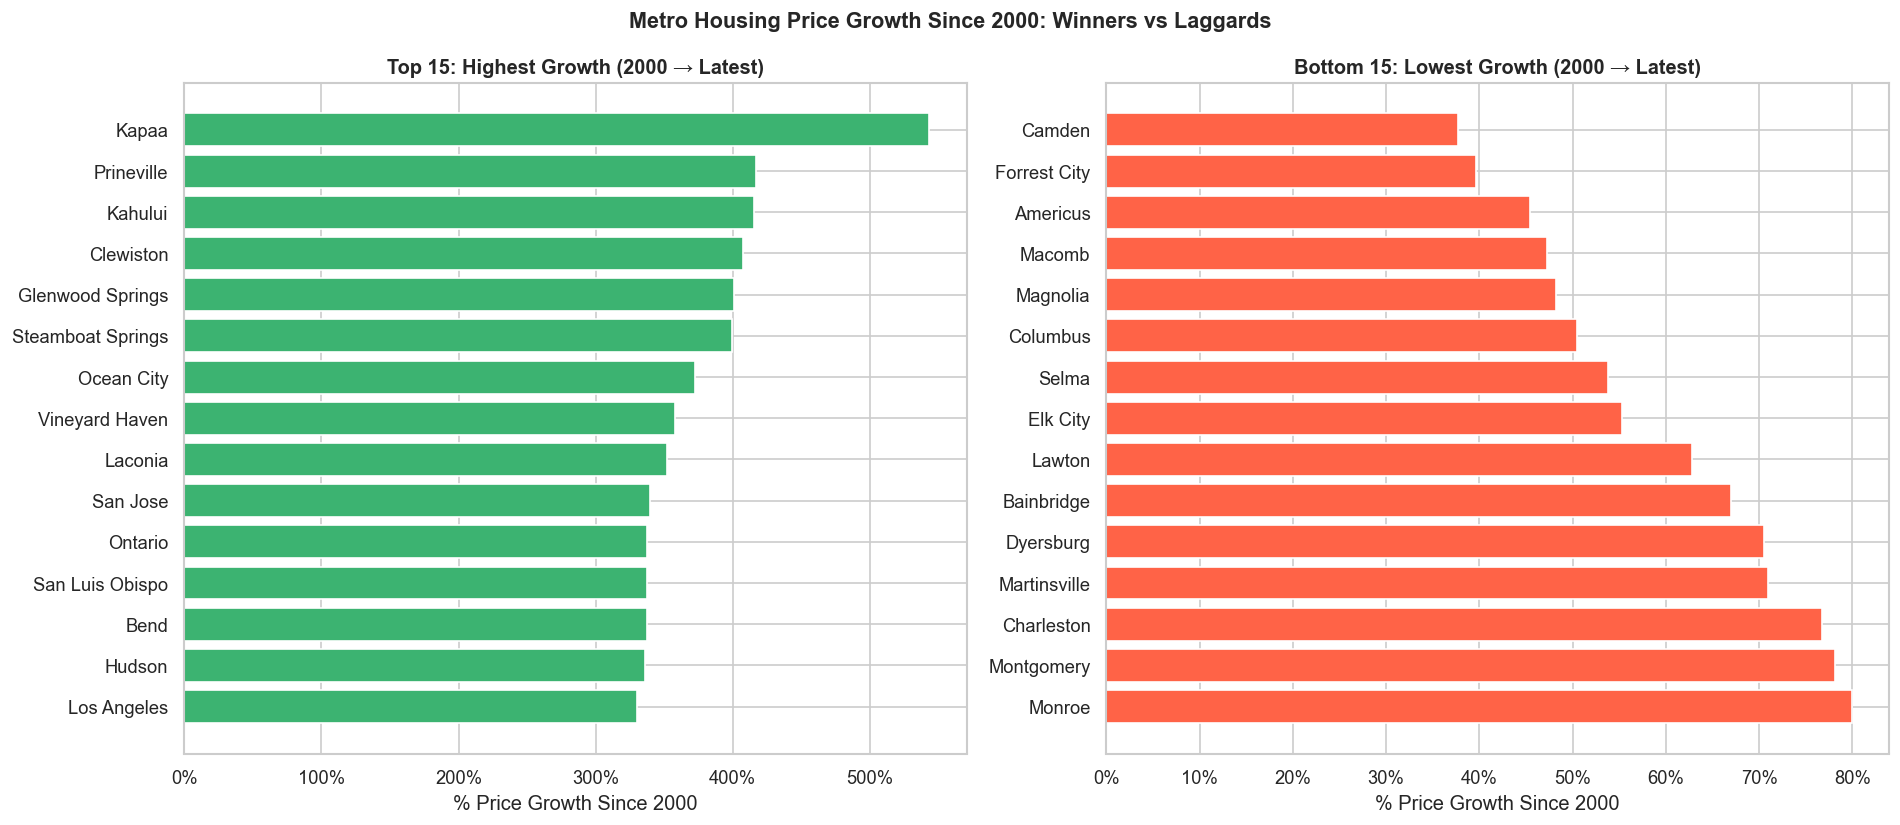

Figure 3 saved.


In [162]:
# ── Fig 3: Top/Bottom 15 Metros by % Growth (Horizontal Bar) ─────────────────
top15    = growth_df.nlargest(15,  'pct_growth_2000_latest')
bottom15 = growth_df.nsmallest(15, 'pct_growth_2000_latest')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, df, title, color in [
    (axes[0], top15,    'Top 15: Highest Growth (2000 → Latest)',  'mediumseagreen'),
    (axes[1], bottom15, 'Bottom 15: Lowest Growth (2000 → Latest)', 'tomato'),
]:
    short = df['RegionName'].str.split(',').str[0]
    ax.barh(short, df['pct_growth_2000_latest'], color=color, edgecolor='white')
    ax.set_xlabel('% Price Growth Since 2000')
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.invert_yaxis()

fig.suptitle('Metro Housing Price Growth Since 2000: Winners vs Laggards',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_growth_bar.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

In [165]:
# ── Fig 4: Interactive Plotly — Price Trajectories ───────────────────────────
interactive_df = zhvi_metro[zhvi_metro['RegionName'].isin(matched)].copy()
interactive_df['Metro'] = interactive_df['RegionName'].str.split(',').str[0]

fig_plotly = px.line(
    interactive_df,
    x='Date', y='ZHVI',
    color='Metro',
    title='Interactive: Metro Housing Prices 2000–2026 (hover for details)',
    labels={'ZHVI': 'Home Value Index ($)', 'Date': 'Date'},
    template='plotly_white',
    height=560
)
fig_plotly.update_traces(line=dict(width=2))
fig_plotly.add_vline(x=pd.to_datetime('2008-09-01'), line_dash='dash', line_color='red', 
                     annotation_text='2008 Crisis', 
                     annotation_position='top left', annotation_font_size=10)
# Fix for the COVID-19 line
fig_plotly.add_vline(x=pd.to_datetime('2020-03-01'), line_dash='dash', line_color='orange', 
                     annotation_text='COVID-19', 
                     annotation_position='top left', annotation_font_size=10)
fig_plotly.update_layout(
    yaxis_tickformat='$,.0f',
    legend=dict(orientation='v', x=1.01, y=1),
    hovermode='x unified'
)
fig_plotly.write_html(f'{FIGURES_DIR}/fig4_interactive_trajectories.html')
fig_plotly.show()
print('Figure 4 (interactive HTML) saved.')

TypeError: Addition/subtraction of integers and integer-arrays with Timestamp is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`

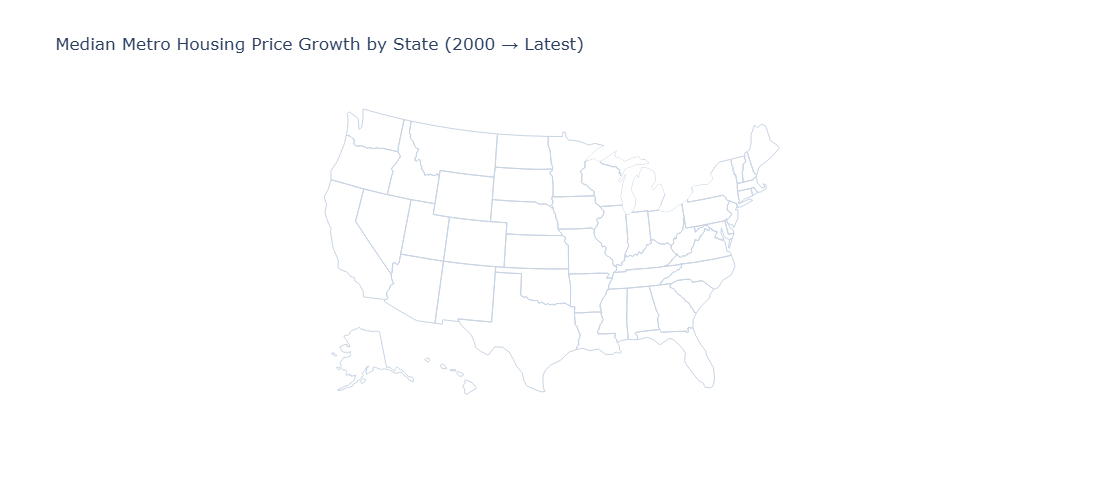

Figure 5 (choropleth HTML) saved.


In [196]:
# ── Fig 5: Choropleth Map — Median % Growth by State ─────────────────────────
STATE_ABBREV = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA',
    'Michigan':'MI','Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT',
    'Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM',
    'New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT',
    'Virginia':'VA','Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY',
    'District of Columbia':'DC'
}

state_growth = (
    growth_df
    .dropna(subset=['StateName'])
    .groupby('StateName')['pct_growth_2000_latest']
    .median()
    .reset_index()
)
state_growth['abbrev'] = state_growth['StateName'].map(STATE_ABBREV)
state_growth = state_growth.dropna(subset=['abbrev'])

fig_map = px.choropleth(
    state_growth,
    locations='abbrev',
    locationmode='USA-states',
    color='pct_growth_2000_latest',
    scope='usa',
    color_continuous_scale='RdYlGn',
    title='Median Metro Housing Price Growth by State (2000 → Latest)',
    labels={'pct_growth_2000_latest': '% Growth', 'abbrev': 'State'},
    template='plotly_white',
    height=480
)
fig_map.update_layout(coloraxis_colorbar=dict(title='% Growth', tickformat='.0f'))
fig_map.write_html(f'{FIGURES_DIR}/fig5_choropleth_growth.html')
fig_map.show()
print('Figure 5 (choropleth HTML) saved.')

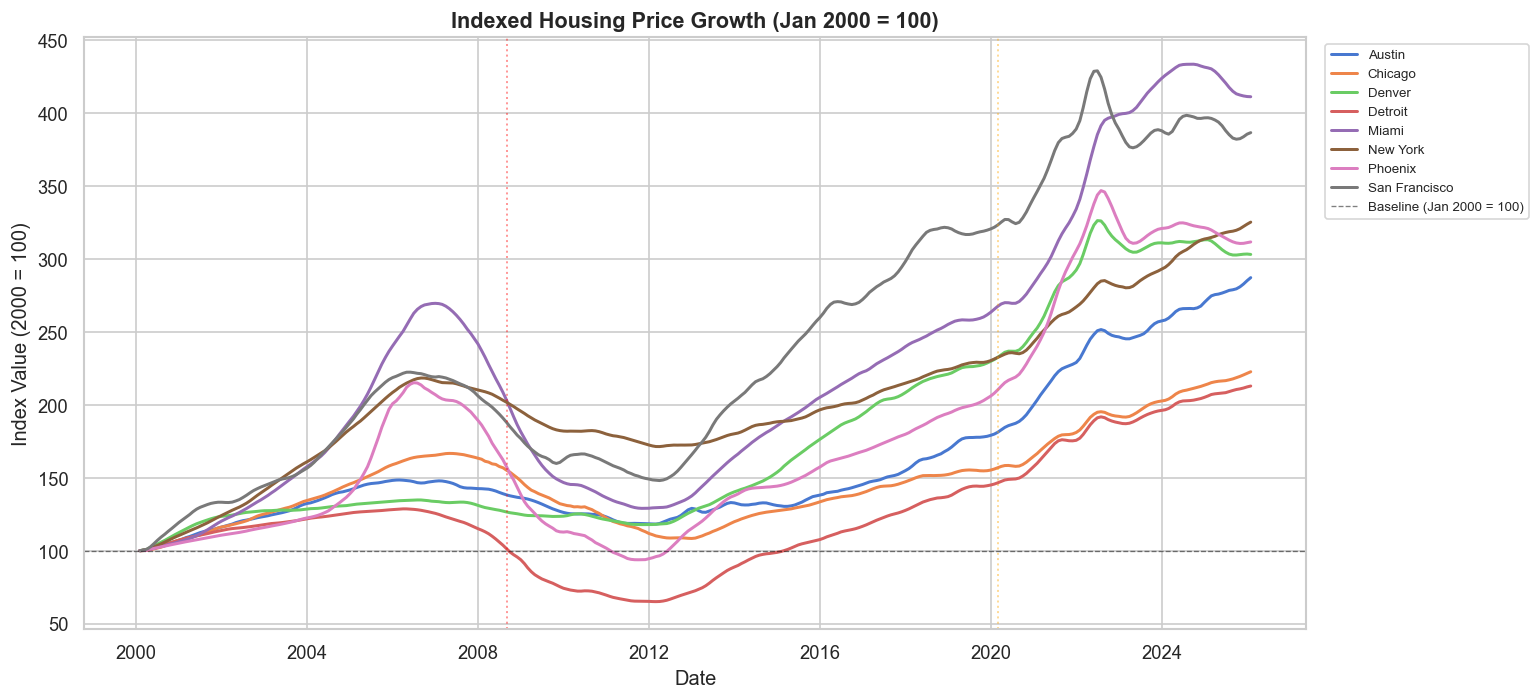

Figure 6 saved.


In [168]:
# ── Fig 6: Indexed Growth (Base = 100 at Jan 2000) ───────────────────────────
# Normalizes all metros to the same starting point to compare relative trajectories

base_snap = zhvi_metro[zhvi_metro['Date'] == zhvi_metro['Date'].min()][['RegionName','ZHVI']]
base_snap = base_snap.rename(columns={'ZHVI': 'ZHVI_base'})

indexed = zhvi_metro.merge(base_snap, on='RegionName')
indexed['ZHVI_idx'] = indexed['ZHVI'] / indexed['ZHVI_base'] * 100

idx_cities = ['San Francisco, CA','Austin, TX','Miami, FL',
              'Detroit, MI','Chicago, IL','Denver, CO','Phoenix, AZ','New York, NY']
idx_metros = [find_metro(m, indexed) for m in idx_cities]
idx_metros = [m for m in idx_metros if m]
idx_plot   = indexed[indexed['RegionName'].isin(idx_metros)]

fig, ax = plt.subplots(figsize=(13, 6))
for name, grp in idx_plot.groupby('RegionName'):
    ax.plot(grp['Date'], grp['ZHVI_idx'], linewidth=1.8, label=name.split(',')[0])

ax.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='Baseline (Jan 2000 = 100)')
ax.axvline(pd.Timestamp('2008-09-01'), color='red',    linestyle=':', alpha=0.4, linewidth=1.2)
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle=':', alpha=0.4, linewidth=1.2)
ax.set_title('Indexed Housing Price Growth (Jan 2000 = 100)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value (2000 = 100)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_indexed_growth.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

---
## Part 4 — Summary Tables

In [178]:
# ── Table 1: Top 15 Metro Growth Rankings ────────────────────────────────────
top15_table = (
    growth_df.nlargest(15, 'pct_growth_2000_latest')
    [['RegionName','StateName','zhvi_2000','zhvi_latest','pct_growth_2000_latest']]
    .reset_index(drop=True)
)
top15_table.index += 1
top15_table.columns = ['Metro','State','ZHVI (2000)','ZHVI (Latest)','% Growth']

print('Top 15 Metros by Price Growth (2000 to Latest):')
top15_table.style.format({
    'ZHVI (2000)':   '${:,.0f}',
    'ZHVI (Latest)': '${:,.0f}',
    '% Growth':      '{:.1f}%'
})

Top 15 Metros by Price Growth (2000 to Latest):


,Metro,State,ZHVI (2000),ZHVI (Latest),% Growth
1,"Kapaa, HI",HI,"$154,102","$991,658",543.5%
2,"Prineville, OR",OR,"$88,936","$459,753",416.9%
3,"Kahului, HI",HI,"$191,801","$988,552",415.4%
4,"Clewiston, FL",FL,"$53,539","$271,874",407.8%
5,"Glenwood Springs, CO",CO,"$191,404","$958,259",400.6%
6,"Steamboat Springs, CO",CO,"$220,316","$1,099,875",399.2%
7,"Ocean City, NJ",NJ,"$161,975","$765,863",372.8%
8,"Vineyard Haven, MA",MA,"$323,150","$1,479,928",358.0%
9,"Laconia, NH",NH,"$108,456","$489,854",351.7%
10,"San Jose, CA",CA,"$356,515","$1,568,567",340.0%


In [194]:
# ── Table 2: Annual Price Spread Summary ─────────────────────────────────────
spread_annual = (
    spread_df.set_index('Date')
    .resample('YE')
    .last()[['spread_abs','avg_zhvi','spread_ratio']]
)
spread_annual.columns = ['Spread Max-Min ($)','Avg ZHVI ($)','Max/Min Ratio']
spread_annual['Spread Growth vs 2000'] = (
    (spread_annual['Spread Max-Min ($)'] / spread_annual['Spread Max-Min ($)'].iloc[0] - 1) * 100
).round(1)
spread_annual.index = spread_annual.index.year
spread_annual.index.name = 'Year'

print('Annual Price Spread (every 3rd year shown):')
spread_annual.iloc[::3].style.format({
    'Spread Max-Min ($)':    '${:,.0f}',
    'Avg ZHVI ($)':          '${:,.0f}',
    'Max/Min Ratio':         '{:.2f}x',
    'Spread Growth vs 2000': '{:.1f}%'
})

Annual Price Spread (every 3rd year shown):


,Spread Max-Min ($),Avg ZHVI ($),Max/Min Ratio,Spread Growth vs 2000
Year,,,,
2000,"$395,126","$114,035",9.48x,0.0%
2003,"$479,658","$139,159",10.65x,21.4%
2006,"$622,001","$176,912",11.77x,57.4%
2009,"$529,365","$146,943",10.38x,34.0%
2012,"$545,389","$139,283",11.07x,38.0%
2015,"$809,961","$161,120",15.01x,105.0%
2018,"$1,133,544","$184,926",23.22x,186.9%
2021,"$1,297,067","$247,018",22.00x,228.3%
2024,"$1,541,969","$282,893",31.63x,290.2%


In [195]:
# ── Table 3: State-Level Summary ─────────────────────────────────────────────
print('Top 10 States by Median Metro Price Growth (2000 to Latest):')
state_agg.head(10).rename(columns={
    'median_growth_00': 'Median Growth 2000-Latest (%)',
    'median_growth_09': 'Median Growth 2009-2024 (%)',
    'median_zhvi':      'Median ZHVI ($)',
    'num_metros':       '# Metros',
    'StateName':        'State'
}).style.format({
    'Median Growth 2000-Latest (%)': '{:.1f}%',
    'Median Growth 2009-2024 (%)':   '{:.1f}%',
    'Median ZHVI ($)':               '${:,.0f}'
})

Top 10 States by Median Metro Price Growth (2000 to Latest):


,State,# Metros,Median Growth 2000-Latest (%),Median Growth 2009-2024 (%),Median ZHVI ($)
10,HI,3,415.4%,123.8%,"$988,552"
26,NH,5,289.2%,113.4%,"$468,928"
20,ME,4,280.2%,113.6%,"$308,590"
12,ID,1,264.5%,112.6%,"$399,402"
3,AZ,8,262.6%,97.3%,"$359,370"
34,RI,1,261.4%,92.9%,"$501,113"
4,CA,20,253.8%,117.4%,"$798,236"
41,WA,7,241.9%,108.3%,"$518,309"
32,OR,14,241.8%,97.8%,"$442,974"
40,VT,4,224.8%,74.2%,"$367,688"


In [191]:
# ── Close DB ────────────────────────────────────────────────────────
conn.close()

print('Database connection closed.')
print(f'\nFigures saved to ./{FIGURES_DIR}/')
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f'  {f}')
print('\n=== Notebook Complete ===')

Database connection closed.

Figures saved to ./figures/
  fig1_metro_trajectories.png
  fig1_top_metro_trajectories.png
  fig2_price_divergence.png
  fig3_growth_bar.png
  fig5_choropleth_growth.html
  fig6_indexed_growth.png

=== Notebook Complete ===
